In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
# pip install yfinance

In [3]:
df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [4]:
print(df.shape)
print(df.isnull().sum())

(2264, 5)
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


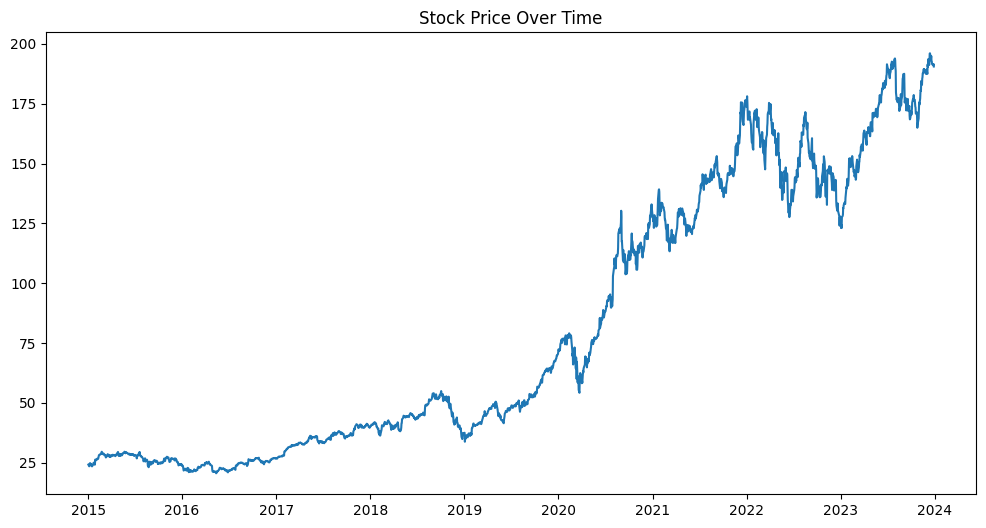

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title('Stock Price Over Time')
plt.show()

In [6]:
df['Target'] = df['Close'].shift(-1)

df = df.dropna()

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [8]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [12]:
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")

Mean Absolute Error: $4.97
Root Mean Squared Error: $7.43


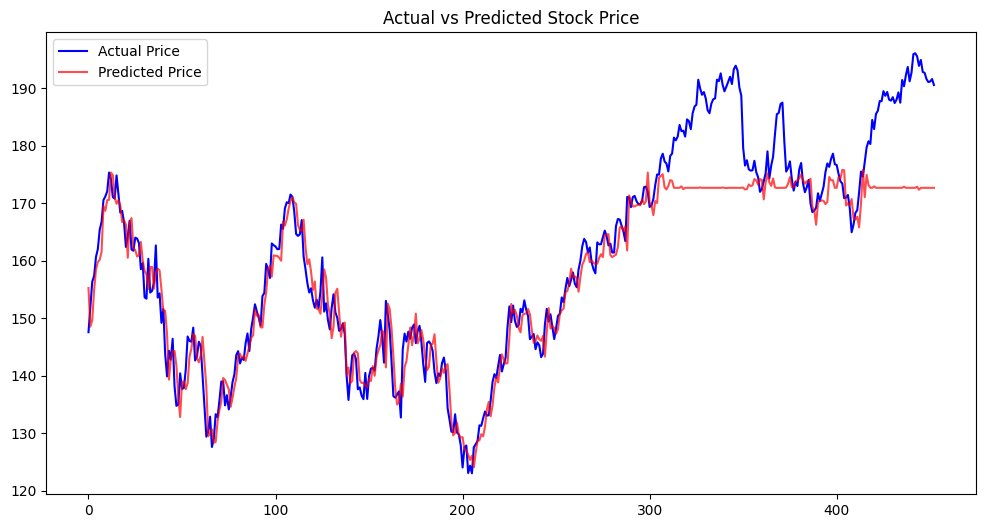

In [13]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red', alpha=0.7)
plt.title('Actual vs Predicted Stock Price')
plt.legend()
plt.show()